Q2 - Unsupervised Learning (Customer Segmentation using K-Means)

In [ ]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


1. Data Preparation

Why scaling is important?

K-Means clustering is distance based algorithm. It uses Euclidean distance.

If features are not scaled:
- Features with large values (like annual_spend) will dominate
- Features with small values (like visits_per_month) will be ignored

So we use StandardScaler to bring all features to same scale.


In [ ]:
#loading dataset
df = pd.read_csv('../data/q2_customers.csv')

#printing first few rows
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [ ]:
#scaling the data
scaler = StandardScaler()

#fit and transform
scaled_data = scaler.fit_transform(df)

#convert back to dataframe for easy understanding
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


2. Choosing K using Elbow Method

We calculate WCSS (Within Cluster Sum of Squares) for different K values.

We select K where the graph forms an "elbow".
After that point, improvement becomes small.


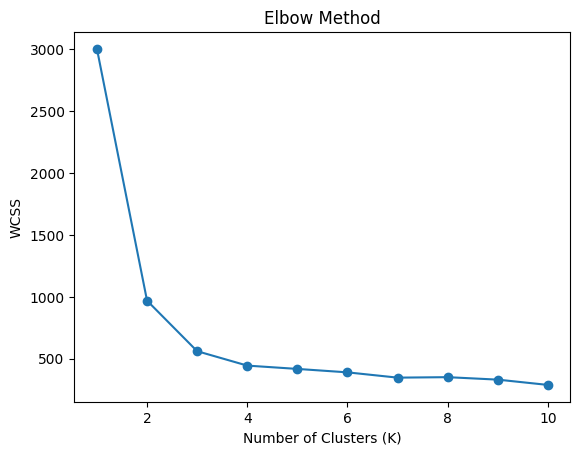

In [ ]:
#calculating WCSS
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

#plotting elbow graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()


Optimal K Selection

From the graph, we can see the elbow point at K = 3.

After K=3, the reduction in WCSS is very small.

So we select K = 3.

In [ ]:
#applying KMeans with chosen K
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(scaled_df)

#adding cluster column
df['cluster'] = clusters

df.head()


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [ ]:
#printing centroids

centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroids = pd.DataFrame(centroids_original, columns=df.columns[:-1])

centroids


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster Interpretation

- Cluster 0: Young customers who come very frequently but spend less money. Small purchases and fewer categories.
- Cluster 1: Older customers who come less often but spend very high. Big purchases and buy many categories.
- Cluster 2: Middle-aged customers with average visits and average spending. Normal balanced behaviour.


4. PCA (Dimensionality Reduction)

We reduce data to 2 dimensions for visualization.


In [ ]:
#applying PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

#explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

#loadings
loadings = pd.DataFrame(pca.components_, columns=df.columns[:-1], index=['PC1', 'PC2'])

loadings


Explained Variance Ratio:
[0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PCA Interpretation

- PC1 (Principal Component 1) : PC1 mainly represents overall customer value and spending behaviour.
Features like annual_spend, basket_size, number of categories and age have high positive values, while visits_per_month is negative.
- PC2 (Principal Component 2) : PC2 is mainly dominated by days_since_last_visit, which has a very high value.


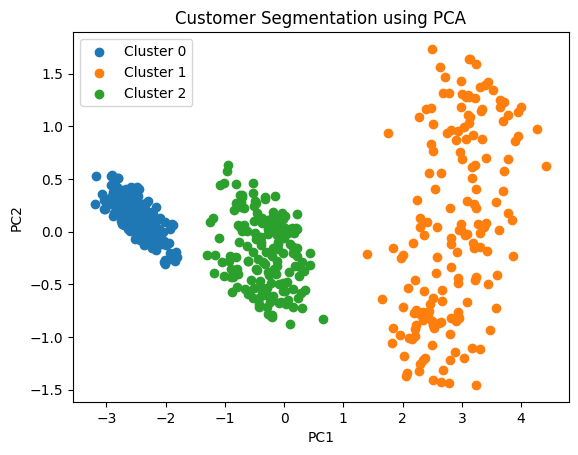

In [14]:
#Cluster Visualisation 

#creating dataframe for PCA
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = clusters

#plotting
plt.figure()

for i in range(k):
    plt.scatter(pca_df[pca_df['cluster'] == i]['PC1'],
                pca_df[pca_df['cluster'] == i]['PC2'],
                label=f'Cluster {i}')

plt.title('Customer Segmentation using PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()
